# LoRa Chirps in AWGN: SF7-SF12 Error Curves

This standalone NumPy and Matplotlib notebook measures symbol-error rate for ideal cyclic chirps, complex additive white Gaussian noise, and dechirp-plus-FFT detection. It does not require Sionna.

> It intentionally excludes packet FEC, synchronization error, fading, Doppler, interference, and collisions. Those belong in later link-level tutorials.

## 1. Simulation SNR and receiver noise floor

The simulation uses normalized sample SNR. To map it approximately to a receiver, use:

$$N_{dBm}=-174+10\log_{10}(BW)+NF, \qquad P_r=N_{dBm}+SNR_{dB}.$$

In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.25})

BW_HZ = 812_500.0
NOISE_FIGURE_DB = 6.0
SNR_DB = np.arange(-28, 3, 2)
TRIALS_PER_POINT = 200
RNG = np.random.default_rng(2026)

noise_floor_dbm = -174 + 10 * np.log10(BW_HZ) + NOISE_FIGURE_DB
print(f"approximate noise floor: {noise_floor_dbm:.1f} dBm")
print(f"-8 dB sample SNR maps to roughly {noise_floor_dbm - 8:.1f} dBm")

approximate noise floor: -108.9 dBm
-8 dB sample SNR maps to roughly -116.9 dBm


## 2. Ideal CSS transmitter and FFT-bin receiver

For M = 2^SF samples per symbol, a cyclic shift of the up-chirp represents one symbol. Dechirping converts that shift to a tone; the largest FFT bin is the detected symbol.

In [8]:
def reference_upchirp(sf):
    m = 1 << sf
    n = np.arange(m)
    return np.exp(1j * 2 * np.pi * (n**2 / (2 * m) - n / 2))

def lora_symbol(symbol, sf):
    m = 1 << sf
    if not 0 <= symbol < m:
        raise ValueError(f"symbol must be in [0, {m})")
    return np.roll(reference_upchirp(sf), -symbol)

def detect_symbol(samples, sf):
    dechirped = samples * np.conj(reference_upchirp(sf))
    return int(np.argmax(np.abs(np.fft.fft(dechirped))))

def add_awgn(samples, snr_db, rng):
    noise_power = np.mean(np.abs(samples) ** 2) / (10 ** (snr_db / 10))
    noise = np.sqrt(noise_power / 2) * (rng.standard_normal(samples.size) + 1j * rng.standard_normal(samples.size))
    return samples + noise

# Runnable correctness check: an ideal symbol must round-trip exactly.
for sf in (7, 12):
    m = 1 << sf
    for symbol in (0, 1, m // 2, m - 1):
        assert detect_symbol(lora_symbol(symbol, sf), sf) == symbol
print("Ideal SF7 and SF12 round-trip checks passed.")

Ideal SF7 and SF12 round-trip checks passed.


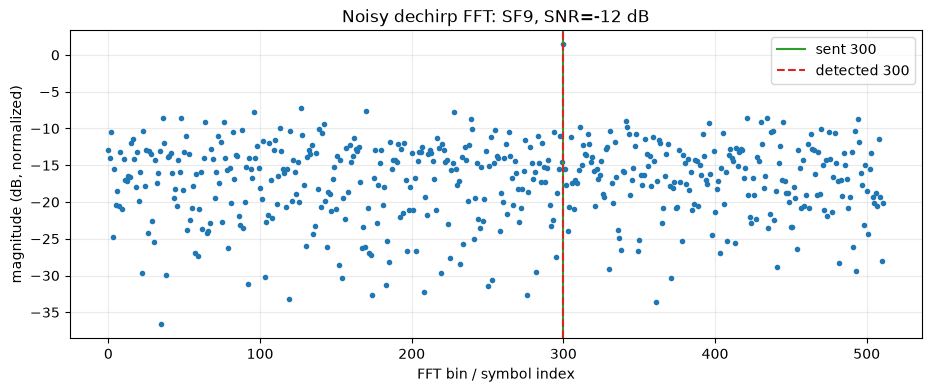

In [9]:
sf, symbol, snr_db = 9, 300, -12
received = add_awgn(lora_symbol(symbol, sf), snr_db, RNG)
spectrum = np.fft.fft(received * np.conj(reference_upchirp(sf)))
detected = detect_symbol(received, sf)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(20 * np.log10(np.maximum(np.abs(spectrum) / len(spectrum), 1e-12)), marker=".", linestyle="none")
ax.axvline(symbol, color="tab:green", label=f"sent {symbol}")
ax.axvline(detected, color="tab:red", linestyle="--", label=f"detected {detected}")
ax.set(title=f"Noisy dechirp FFT: SF{sf}, SNR={snr_db} dB", xlabel="FFT bin / symbol index", ylabel="magnitude (dB, normalized)")
ax.legend()
plt.show()

## 3. Monte-Carlo SER: noise power versus energy per bit

At each SNR, send random symbols through fresh AWGN and count detector mistakes. Here $F_s=BW$, $M=2^{SF}$, and no FEC is applied, so $SF$ information bits occupy one $M$-sample symbol:

$$E_s/N_0=M\,SNR,\qquad E_b/N_0=\frac{M}{SF}\,SNR.$$

In dB, add $10\log_{10}(M/SF)$ to sample SNR to obtain $E_b/N_0$. The two panels below replot **the same measured errors** on different horizontal axes. The vertical axis is the fraction of wrong chirp-symbol decisions, not a power in dB. Higher SF's large apparent advantage at fixed SNR includes the energy spent transmitting a longer symbol.

For a coded payload, $R_b\approx R_c SF\,BW/M$ gives $E_b/N_0=SNR\,M/(R_c SF)$, but adding this axis conversion does not simulate a decoder. Packet overhead needs a separate energy accounting convention. Sionna's OFDM examples can use 5G NR LDPC codes: OFDM and a BLER plot alone do not make an example IEEE 802.11.

Sionna's `ebnodb2no` assumes unit energy per constellation symbol (with optional OFDM overhead accounting). Our chirp has unit power per sample and $M$ samples, so its discrete energy is $M$. Preserve that factor when adapting the noise calculation; copying a QAM normalization directly would change the experiment.

Only 200 trials per point are used by default. Zero observed errors means an upper bound, not a measured error floor: the one-sided 95% binomial bound is $1-0.05^{1/N}$ for zero errors in $N$ independent trials. One downward triangle per SF shows the bound at its first zero-error point; later zero-error points are omitted to keep the plot readable. Solid curves use only nonzero estimates.

In [10]:
def simulate_ser(sf, snr_values, trials, rng):
    m = 1 << sf
    output = []
    for snr_db in snr_values:
        errors = 0
        for _ in range(trials):
            sent = int(rng.integers(m))
            errors += detect_symbol(add_awgn(lora_symbol(sent, sf), snr_db, rng), sf) != sent
        output.append(errors / trials)
    return np.array(output)

ser_by_sf = {sf: simulate_ser(sf, SNR_DB, TRIALS_PER_POINT, RNG) for sf in range(7, 13)}
print("Monte-Carlo simulation complete.")

Monte-Carlo simulation complete.


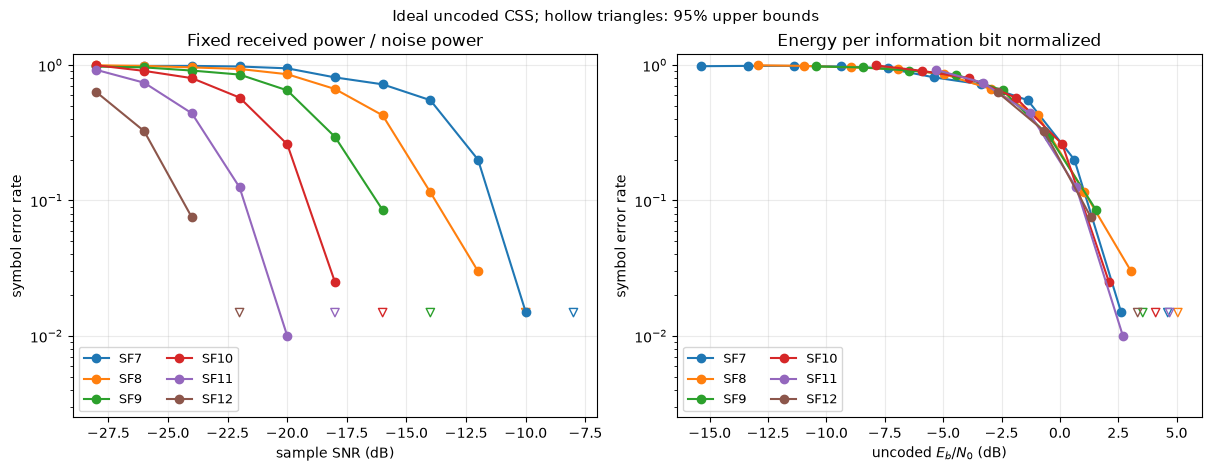

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
zero_error_upper = 1 - 0.05 ** (1 / TRIALS_PER_POINT)
assert np.isclose(-8 + 10 * np.log10(128 / 7), 4.621119, atol=1e-5)
for sf, ser in ser_by_sf.items():
    ebno_db = SNR_DB + 10 * np.log10((1 << sf) / sf)
    first_zero = np.flatnonzero(ser == 0)[:1]
    for ax, horizontal in zip(axes, (SNR_DB, ebno_db)):
        line, = ax.semilogy(horizontal, np.where(ser > 0, ser, np.nan), 'o-', label=f'SF{sf}')
        ax.scatter(horizontal[first_zero], np.full(first_zero.size, zero_error_upper), marker='v', facecolors='none', edgecolors=line.get_color())
for ax, xlabel in zip(axes, ('sample SNR (dB)', r'uncoded $E_b/N_0$ (dB)')):
    ax.set(xlabel=xlabel, ylabel='symbol error rate', ylim=(0.5 / TRIALS_PER_POINT, 1.2))
    ax.legend(ncol=2, fontsize=9)
axes[0].set_title('Fixed received power / noise power')
axes[1].set_title('Energy per information bit normalized')
fig.suptitle('Ideal uncoded CSS; hollow triangles: 95% upper bounds', fontsize=11)
plt.show()

## 4. From SER to an uncoded packet-error estimate

For $N_s$ independently detected, uncoded payload symbols, $PER\approx1-(1-SER)^{N_s}$. This neglects synchronization, FEC, headers, and CRC detection. Holding 32 symbols fixed changes the number of payload bits across SFs; it is not a fixed-payload comparison.

BLER is the fraction of blocks with at least one wrong decoded bit. LoRa PER is the analogous whole-packet failure metric once a complete packet receiver is included. In a simulation it can be counted against the known transmitted payload; hardware generally reports CRC acceptance. A block and a packet need not have the same length or boundaries.

The downward triangles below transform the SER upper bound through the independent-symbol model. With few trials, even zero symbol errors cannot establish a low packet error rate. For IoT, a packet failure loses a complete sensor reading and may trigger a retransmission.

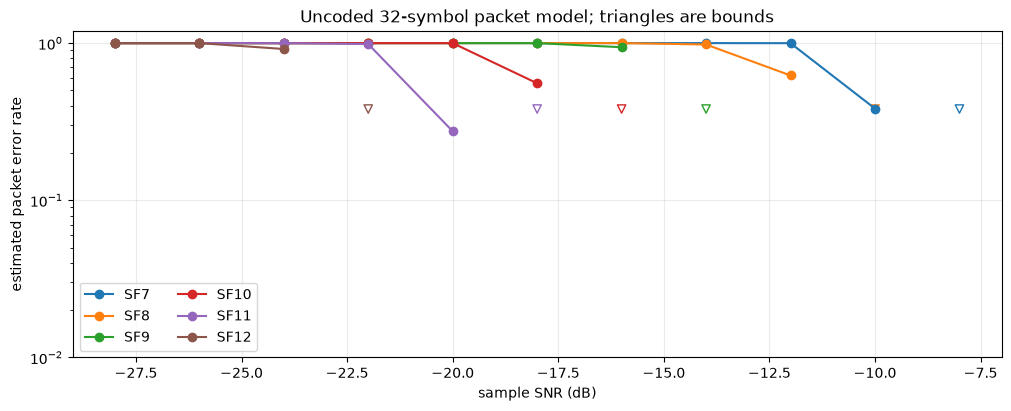

In [12]:
PACKET_SYMBOLS = 32
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
for sf, ser in ser_by_sf.items():
    per = 1 - (1 - ser) ** PACKET_SYMBOLS
    line, = ax.semilogy(SNR_DB, np.where(ser > 0, per, np.nan), 'o-', label=f'SF{sf}')
    upper = 1 - (1 - zero_error_upper) ** PACKET_SYMBOLS
    first_zero = np.flatnonzero(ser == 0)[:1]
    ax.scatter(SNR_DB[first_zero], np.full(first_zero.size, upper), marker='v', facecolors='none', edgecolors=line.get_color())
ax.set(title=f'Uncoded {PACKET_SYMBOLS}-symbol packet model; triangles are bounds', xlabel='sample SNR (dB)', ylabel='estimated packet error rate', ylim=(0.01, 1.2))
ax.legend(ncol=2)
plt.show()

## Takeaways

- The -8 dB example is an SNR, not a noise-floor or antenna-gain value.
- Higher SF gives a longer chirp and more evidence for the FFT-bin decision, but halves symbol rate at each SF increment.
- These curves isolate CSS detection in AWGN. The next realistic step is to connect packet FEC from the packet-PHY tutorial, then add multipath, Doppler, interference, and a Sionna channel.

## Focused references

- A. Maleki et al., [CSS tutorial](https://arxiv.org/abs/2310.10503): detector and error-rate derivations.
- Sionna [Neural Receiver for OFDM SIMO Systems](https://nvlabs.github.io/sionna/phy/tutorials/notebooks/Neural_Receiver.html): a BLER versus $E_b/N_0$ comparison using 5G NR LDPC, not a Wi-Fi packet implementation.